In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv('preprocessed_kidney_data.csv')
print(f"Shape: {df.shape}  →  {df.shape[0]} records, {df.shape[1]} features")
pd.set_option('display.max_columns', None)
df.head()

Shape: (400, 25)  →  400 records, 25 features


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44.0,7800.0,5.2,yes,yes,no,good,no,no,1
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38.0,6000.0,NaN,no,no,no,good,no,no,1
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31.0,7500.0,NaN,no,yes,no,poor,no,yes,1
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,1
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35.0,7300.0,4.6,no,no,no,good,no,no,1


In [3]:
X = df.drop(columns=['classification'])
y = df['classification']
print(f"Features matrix X: {X.shape}")
print(f"Target vector  y: {y.shape}")

Features matrix X: (400, 24)
Target vector  y: (400,)


# Splitting the dataset

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Training Set : {X_train.shape[0]} records")
print(f"Testing Set  : {X_test.shape[0]} records")
print(f"\nClass balance in train:\n{y_train.value_counts()}")
print(f"\nClass balance in test:\n{y_test.value_counts()}")

Training Set : 320 records
Testing Set  : 80 records

Class balance in train:
classification
1    200
0    120
Name: count, dtype: int64

Class balance in test:
classification
1    50
0    30
Name: count, dtype: int64


In [5]:
# Identify quantitative and qualitative columns from training split
quan = X_train.select_dtypes(include=['number']).columns.tolist()
qual = X_train.select_dtypes(exclude=['number']).columns.tolist()

print(f"Quantitative columns ({len(quan)}): {quan}")
print(f"Qualitative  columns ({len(qual)}): {qual}")

Quantitative columns (14): ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']
Qualitative  columns (10): ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']


In [6]:
# ── Descriptive stats on TRAINING SPLIT only ───────────────────────────────
descriptive = pd.DataFrame(
    index=["Mean","Median","Mode","Q1:25%","Q2:50%","Q3:75%","Q4:100%",
           "IQR","1.5rule","Lesser","Greater","Min","Max","Skewness","Kurtosis"],
    columns=quan
)

for col in quan:
    desc = X_train[col].describe()
    descriptive.loc["Mean",    col] = X_train[col].mean()
    descriptive.loc["Median",  col] = X_train[col].median()
    descriptive.loc["Mode",    col] = X_train[col].mode()[0] if not X_train[col].mode().empty else np.nan
    descriptive.loc["Q1:25%",  col] = desc["25%"]
    descriptive.loc["Q2:50%",  col] = desc["50%"]
    descriptive.loc["Q3:75%",  col] = desc["75%"]
    descriptive.loc["Q4:100%", col] = desc["max"]
    iqr = desc["75%"] - desc["25%"]
    descriptive.loc["IQR",     col] = iqr
    descriptive.loc["1.5rule", col] = 1.5 * iqr
    descriptive.loc["Lesser",  col] = desc["25%"] - 1.5 * iqr
    descriptive.loc["Greater", col] = desc["75%"] + 1.5 * iqr
    descriptive.loc["Min",     col] = X_train[col].min()
    descriptive.loc["Max",     col] = X_train[col].max()
    descriptive.loc["Skewness",col] = X_train[col].skew()
    descriptive.loc["Kurtosis",col] = X_train[col].kurtosis()

display(descriptive)

,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc
Mean,51.086538,76.763754,1.017384,1.003571,0.388489,145.053191,57.445847,3.148355,137.042857,4.352459,12.518773,38.675573,8403.813559,4.716279
Median,54.0,80.0,1.02,0.0,0.0,120.5,42.0,1.2,138.0,4.3,12.6,40.0,8100.0,4.8
Mode,60.0,70.0,1.02,0.0,0.0,99.0,25.0,1.2,135.0,5.0,15.0,41.0,9200.0,5.2
Q1:25%,42.0,70.0,1.01,0.0,0.0,100.0,27.0,0.9,135.0,3.8,10.4,32.0,6300.0,3.9
Q2:50%,54.0,80.0,1.02,0.0,0.0,120.5,42.0,1.2,138.0,4.3,12.6,40.0,8100.0,4.8
Q3:75%,64.0,80.0,1.02,2.0,0.0,156.0,66.0,2.9,142.0,4.9,15.0,45.0,9800.0,5.5
Q4:100%,90.0,180.0,1.025,5.0,5.0,490.0,322.0,76.0,150.0,7.6,17.8,54.0,26400.0,6.5
IQR,22.0,10.0,0.01,2.0,0.0,56.0,39.0,2.0,7.0,1.1,4.6,13.0,3500.0,1.6
1.5rule,33.0,15.0,0.015,3.0,0.0,84.0,58.5,3.0,10.5,1.65,6.9,19.5,5250.0,2.4
Lesser,9.0,55.0,0.995,-3.0,0.0,16.0,-31.5,-2.1,124.5,2.15,3.5,12.5,1050.0,1.5


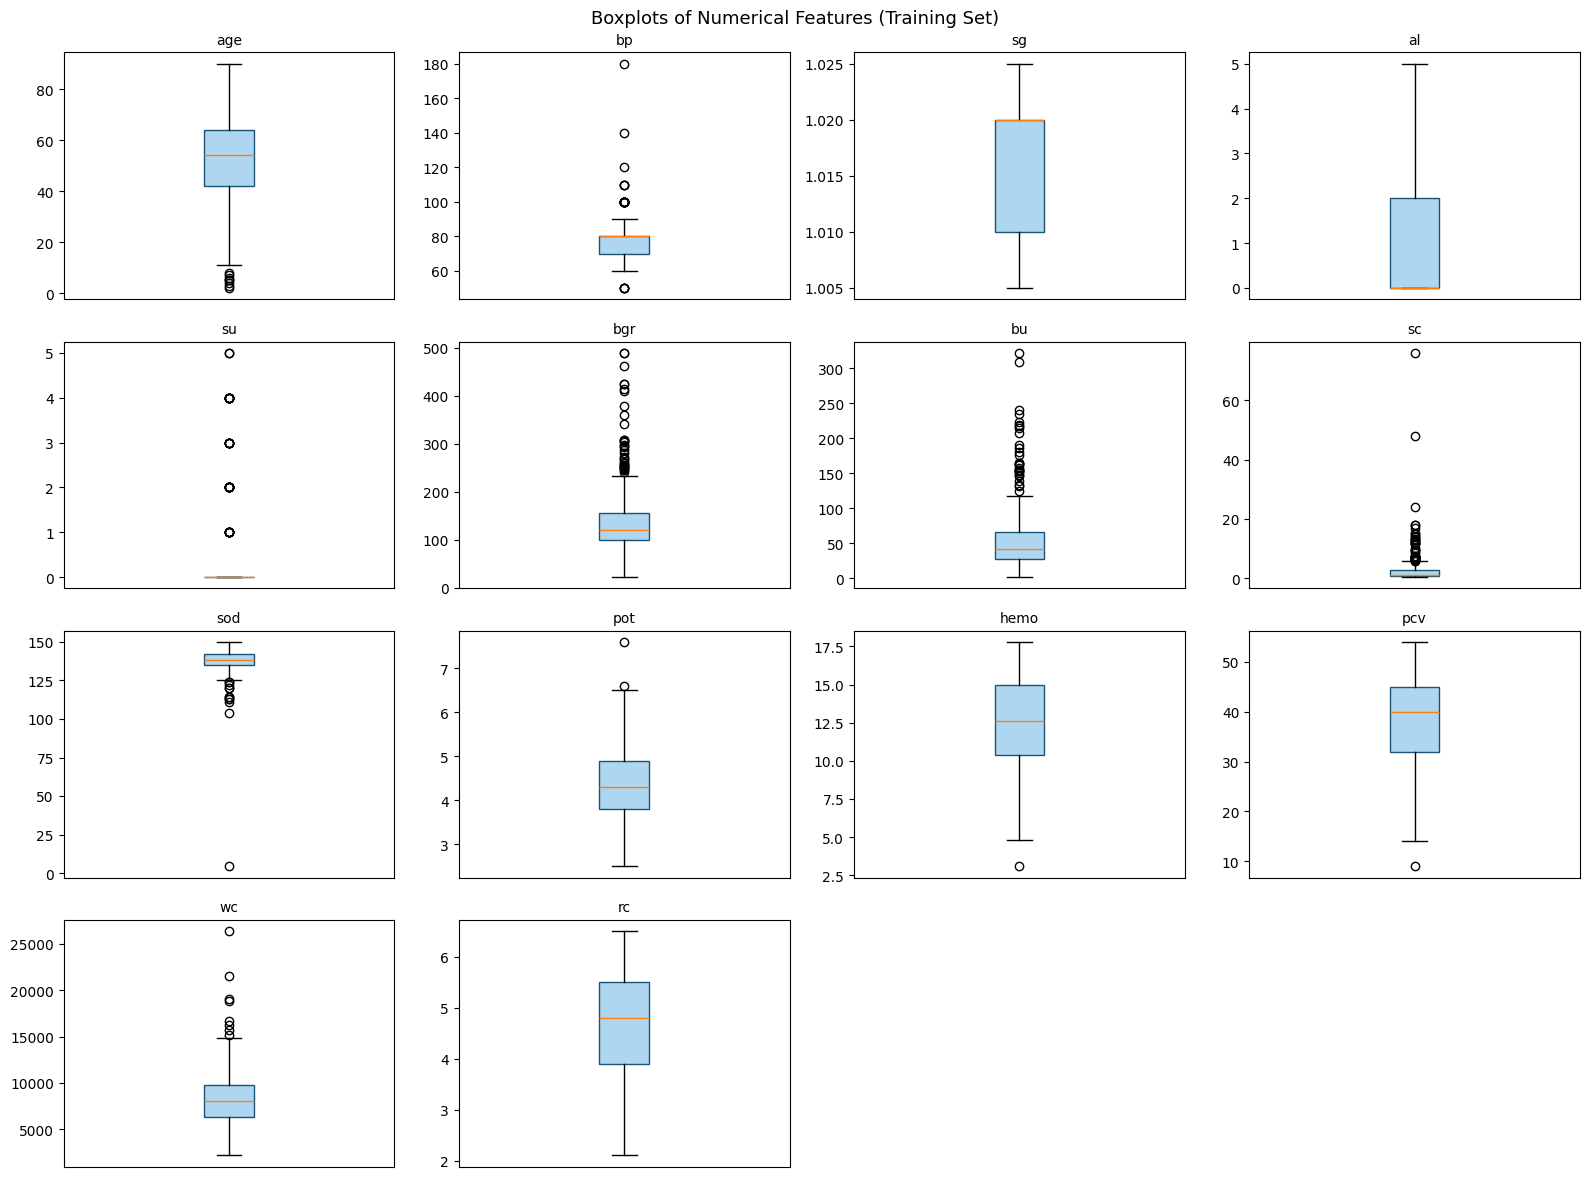

In [7]:
# ── Boxplots for visual outlier detection ──────────────────────────────────
# FIX (NEW STEP): Boxplots were missing in the original notebook
n_cols = 4
n_rows = (len(quan) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(quan):
    axes[i].boxplot(X_train[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#AED6F1', color='#1A5276'))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xticks([])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots of Numerical Features (Training Set)', fontsize=13)
plt.tight_layout()
plt.show()

In [8]:
def OutlierDetector(Quan, descriptive_df, data_df):
    """
    Identifies low and high outliers, returning master tables with columns organized as:
    column_name -> outlier_count -> outlier_% -> threshold -> outlier_range.
    """
    low_summary_data = []
    high_summary_data = []
    LesserOut = []
    GreaterOut = []
    total_rows = len(data_df)
    
    for columnName in Quan:
        lesser_threshold = descriptive_df.loc["Lesser", columnName]
        greater_threshold = descriptive_df.loc["Greater", columnName]
        
        # 1. Process Low Outliers
        low_vals = data_df[data_df[columnName] < lesser_threshold][columnName].tolist()
        if len(low_vals) > 0:
            LesserOut.append(columnName)
            low_min, low_max = min(low_vals), max(low_vals)
            range_str = f"[{low_min}]" if low_min == low_max else f"[{low_min} to {low_max}]"
            
            low_summary_data.append({
                "column_name": columnName,
                "outlier_count": len(low_vals),
                "outlier_%": f"{(len(low_vals) / total_rows) * 100:.2f}%",
                "lesser_threshold": lesser_threshold,
                "outlier_range": range_str
            })
            
        # 2. Process High Outliers
        high_vals = data_df[data_df[columnName] > greater_threshold][columnName].tolist()
        if len(high_vals) > 0:
            GreaterOut.append(columnName)
            high_min, high_max = min(high_vals), max(high_vals)
            range_str = f"[{high_min}]" if high_min == high_max else f"[{high_min} to {high_max}]"
            
            high_summary_data.append({
                "column_name": columnName,
                "outlier_count": len(high_vals),
                "outlier_%": f"{(len(high_vals) / total_rows) * 100:.2f}%",
                "greater_threshold": greater_threshold,
                "outlier_range": range_str
            })
            
    df_low = pd.DataFrame(low_summary_data)
    df_high = pd.DataFrame(high_summary_data)
        
    return df_low, df_high, LesserOut, GreaterOut

In [9]:
df_low_summary, df_high_summary, lesser_outliers, greater_outliers = OutlierDetector(quan, descriptive, X_train)

print("📉 LOW OUTLIERS TABLE PROFILE:")
display(df_low_summary) 

print("\n📈 HIGH OUTLIERS TABLE PROFILE:")
display(df_high_summary)

📉 LOW OUTLIERS TABLE PROFILE:


,column_name,outlier_count,outlier_%,lesser_threshold,outlier_range
0,age,8,2.50%,9.0,[2.0 to 8.0]
1,bp,4,1.25%,55.0,[50.0]
2,sod,12,3.75%,124.5,[4.5 to 124.0]
3,hemo,1,0.31%,3.5,[3.1]
4,pcv,1,0.31%,12.5,[9.0]



📈 HIGH OUTLIERS TABLE PROFILE:


,column_name,outlier_count,outlier_%,greater_threshold,outlier_range
0,bp,27,8.44%,95.00,[100.0 to 180.0]
1,su,42,13.12%,0.00,[1.0 to 5.0]
2,bgr,33,10.31%,240.00,[241.0 to 490.0]
3,bu,29,9.06%,124.50,[125.0 to 322.0]
4,sc,42,13.12%,5.90,[6.0 to 76.0]
5,pot,2,0.62%,6.55,[6.6 to 7.6]
6,wc,8,2.50%,15050.00,[15200.0 to 26400.0]


In [10]:
def CleanExtremeOutliers(train_df, test_df, floors=None, ceilings=None):
    """
    Applies domain-driven biological thresholds to train and test sets.
    Rows are dropped from the training partition to protect model fitting.
    Test partition samples are safely clipped/capped to prevent target array mismatch.
    """
    train_clean = train_df.copy()
    test_clean  = test_df.copy()
    
    # Initialize a master row mask for training (True means keep the row)
    train_keep_mask = pd.Series(True, index=train_clean.index)

    # 1. Evaluate Low Floors
    if floors:
        for col, floor_val in floors.items():
            if col in train_clean.columns:
                # Identify training rows that break the boundary
                violation_mask = (train_clean[col] < floor_val) & train_clean[col].notna()
                if violation_mask.any():
                    print(f"[TRAIN BOUNDARY] {col}: Flagged {violation_mask.sum()} rows below biological floor ({floor_val})")
                    train_keep_mask &= ~violation_mask
                
                # Safe clipping for evaluation pipeline
                test_clean[col] = test_clean[col].clip(lower=floor_val)

    # 2. Evaluate High Ceilings
    if ceilings:
        for col, ceiling_val in ceilings.items():
            if col in train_clean.columns:
                # Identify training rows that break the boundary
                violation_mask = (train_clean[col] > ceiling_val) & train_clean[col].notna()
                if violation_mask.any():
                    print(f"[TRAIN BOUNDARY] {col}: Flagged {violation_mask.sum()} rows above biological ceiling ({ceiling_val})")
                    train_keep_mask &= ~violation_mask
                
                # Safe clipping for evaluation pipeline
                test_clean[col] = test_clean[col].clip(upper=ceiling_val)

    # Execute dropping logic on training in one fast step
    initial_rows = len(train_clean)
    train_clean = train_clean[train_keep_mask]
    
    print(f"\n✓ Sanitization Complete. Train set size: {initial_rows} ➔ {len(train_clean)} rows.")
    print(f"✓ Test set size preserved: {len(test_clean)} rows (Outliers safely capped).")
    
    return train_clean, test_clean

In [11]:
print(f"Low_floor columns: {df_low_summary['column_name'].unique()}")
print(f"Hihg_ceilings columns: {df_high_summary['column_name'].unique()}")

Low_floor columns: ['age' 'bp' 'sod' 'hemo' 'pcv']
Hihg_ceilings columns: ['bp' 'su' 'bgr' 'bu' 'sc' 'pot' 'wc']


In [12]:
# Updated parameters matching only active outlier columns
low_floors = {"age": 0.0, "bp": 40.0, "sod": 100.0, "hemo": 2.5, "pcv": 8.0}

high_ceilings = {"bp": 200.0, "su": 6.0, "bgr": 600.0, "bu": 450.0,
                 "sc": 20.0, "pot": 10.0, "wc": 30000.0}

# Execution
X_train, X_test = CleanExtremeOutliers(X_train, X_test, floors=low_floors, ceilings=high_ceilings)

# Re-align target labels
y_train = y_train.loc[X_train.index]

print(f"\nAligned y_train size: {y_train.shape}")
print(f"X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")

[TRAIN BOUNDARY] sod: Flagged 1 rows below biological floor (100.0)
[TRAIN BOUNDARY] sc: Flagged 3 rows above biological ceiling (20.0)

✓ Sanitization Complete. Train set size: 320 ➔ 317 rows.
✓ Test set size preserved: 80 rows (Outliers safely capped).

Aligned y_train size: (317,)
X_train shape: (317, 24) | X_test shape: (80, 24)


Class distribution in training set:
classification
1    197
0    120
Name: count, dtype: int64

Imbalance ratio: 1.64:1


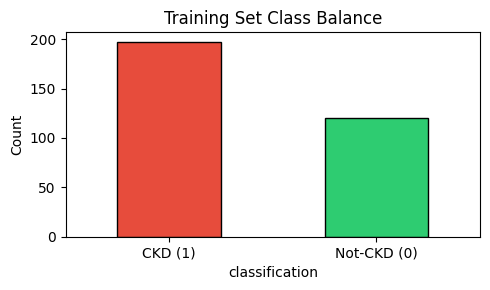


Strategy: Use class_weight='balanced' in classifiers that support it.


In [13]:
print("Class distribution in training set:")
print(y_train.value_counts())
print(f"\nImbalance ratio: {y_train.value_counts().iloc[0] / y_train.value_counts().iloc[1]:.2f}:1")

fig, ax = plt.subplots(figsize=(5, 3))
y_train.value_counts().plot(kind='bar', ax=ax, color=['#E74C3C', '#2ECC71'], edgecolor='black')
ax.set_xticklabels(['CKD (1)', 'Not-CKD (0)'], rotation=0)
ax.set_title('Training Set Class Balance')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()
print("\nStrategy: Use class_weight='balanced' in classifiers that support it.")

In [14]:
def audit_missing_data(dataframe):
    null_count = dataframe.isna().sum()
    null_pct = (dataframe.isna().mean() * 100).round(2)
    
    bins = [-1, 0, 5, 15, 30, 50, 100]
    labels = ['✅ COMPLETE', '🟢 VERY LOW', '🟡 LOW', '🟠 MODERATE', '🔴 HIGH', '❌ DROP']
    tiers = pd.cut(null_pct, bins=bins, labels=labels, right=True).astype(str)
    
    return pd.DataFrame({
        'Missing Count': null_count, 'Missing %': null_pct,
        'dtype': dataframe.dtypes.astype(str), 'Tier': tiers
    }).sort_values('Missing %', ascending=False)

def extract_imputation_lists(dataframe, audit_df):
    num_cols = dataframe.select_dtypes(include=['number']).columns
    cat_cols = dataframe.select_dtypes(exclude=['number']).columns
    pct = audit_df['Missing %']
    
    # Using strict tier boundaries to ensure 0% missing data is separated from 1-5%
    return {
        "drop_col":       audit_df[pct > 50].index.tolist(),
        "high_num":       audit_df[(pct > 30) & (pct <= 50) & audit_df.index.isin(num_cols)].index.tolist(),
        "high_cate":      audit_df[(pct > 30) & (pct <= 50) & audit_df.index.isin(cat_cols)].index.tolist(),
        "mid_num":        audit_df[(pct > 15) & (pct <= 30) & audit_df.index.isin(num_cols)].index.tolist(),
        "mid_cate":       audit_df[(pct > 15) & (pct <= 30) & audit_df.index.isin(cat_cols)].index.tolist(),
        "low_num":        audit_df[(pct > 5)  & (pct <= 15) & audit_df.index.isin(num_cols)].index.tolist(),
        "low_cate":       audit_df[(pct > 5)  & (pct <= 15) & audit_df.index.isin(cat_cols)].index.tolist(),
        "very_low_num":   audit_df[(pct > 0)  & (pct <= 5)  & audit_df.index.isin(num_cols)].index.tolist(),
        "very_low_cate":  audit_df[(pct > 0)  & (pct <= 5)  & audit_df.index.isin(cat_cols)].index.tolist(),
        "complete_num":   audit_df[(pct == 0) & audit_df.index.isin(num_cols)].index.tolist(),
        "complete_cate":  audit_df[(pct == 0) & audit_df.index.isin(cat_cols)].index.tolist(),
    }

In [15]:
# 1. Generate the Audit Table
training_audit = audit_missing_data(X_train)

print('📊 Training Split Automated Missing Value Audit:')
print('=' * 65)
display(training_audit)
print('=' * 65)

# 2. Extract and Unpack Feature Lists
imputation_configs = extract_imputation_lists(X_train, training_audit)
globals().update(imputation_configs)

print('\n🎯 Extracted Feature Tiers Ready for Downstream Transformers:')
for key, feature_list in imputation_configs.items():
    print(f" 🔹 {key:14} (Count: {len(feature_list)}): {feature_list}")

📊 Training Split Automated Missing Value Audit:


,Missing Count,Missing %,dtype,Tier
rbc,123,38.80,object,🔴 HIGH
rc,103,32.49,float64,🔴 HIGH
wc,82,25.87,float64,🟠 MODERATE
pot,74,23.34,float64,🟠 MODERATE
sod,74,23.34,float64,🟠 MODERATE
pcv,57,17.98,float64,🟠 MODERATE
pc,52,16.40,object,🟠 MODERATE
hemo,42,13.25,float64,🟡 LOW
su,40,12.62,float64,🟡 LOW
sg,39,12.30,float64,🟡 LOW



🎯 Extracted Feature Tiers Ready for Downstream Transformers:
 🔹 drop_col       (Count: 0): []
 🔹 high_num       (Count: 1): ['rc']
 🔹 high_cate      (Count: 1): ['rbc']
 🔹 mid_num        (Count: 4): ['wc', 'pot', 'sod', 'pcv']
 🔹 mid_cate       (Count: 1): ['pc']
 🔹 low_num        (Count: 7): ['hemo', 'su', 'sg', 'al', 'bgr', 'bu', 'sc']
 🔹 low_cate       (Count: 0): []
 🔹 very_low_num   (Count: 2): ['bp', 'age']
 🔹 very_low_cate  (Count: 8): ['pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']
 🔹 complete_num   (Count: 0): []
 🔹 complete_cate  (Count: 0): []


## imputation

In [16]:
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import OrdinalEncoder

# Create clean copies of your data
X_train_clean = X_train.copy()
X_test_clean = X_test.copy()

# ==========================================
# 1. DROP STRATEGY (>50% Missing)
# ==========================================
X_train_clean.drop(columns=drop_col, errors='ignore', inplace=True)
X_test_clean.drop(columns=drop_col, errors='ignore', inplace=True)


# ==========================================
# 2. NUMERICAL IMPUTATION
# ==========================================

# --- Very Low Numerical: Median ---
for col in very_low_num:
    median_val = X_train_clean[col].median()
    X_train_clean[col] = X_train_clean[col].fillna(median_val)
    X_test_clean[col]  = X_test_clean[col].fillna(median_val)

# --- Low Numerical: Mean or Median based on Skewness ---
for col in low_num:
    skew_val = X_train_clean[col].skew()
    fill_val = X_train_clean[col].mean() if abs(skew_val) <= 0.5 else X_train_clean[col].median()
    X_train_clean[col] = X_train_clean[col].fillna(fill_val)
    X_test_clean[col]  = X_test_clean[col].fillna(fill_val)

# --- Mid Numerical: MICE ---
if mid_num:
    mice = IterativeImputer(max_iter=10, random_state=42)
    X_train_clean[mid_num] = mice.fit_transform(X_train_clean[mid_num])
    X_test_clean[mid_num]  = mice.transform(X_test_clean[mid_num])

# --- High Numerical: KNN ---
if high_num:
    knn_num = KNNImputer(n_neighbors=5)
    X_train_clean[high_num] = knn_num.fit_transform(X_train_clean[high_num])
    X_test_clean[high_num]  = knn_num.transform(X_test_clean[high_num])


# ==========================================
# 3. CATEGORICAL IMPUTATION
# ==========================================

# --- Simple Categorical (Very Low, Low, Mid): Fill with Mode ---
simple_cat_cols = very_low_cate + low_cate + mid_cate

for col in simple_cat_cols:
    if col in X_train_clean.columns:
        # Calculate the text mode value from your training split
        mode_val = X_train_clean[col].mode()[0]
        X_train_clean[col] = X_train_clean[col].fillna(mode_val)
        X_test_clean[col]  = X_test_clean[col].fillna(mode_val)

# --- High Categorical: KNN (Encoded) + Flag ---
if high_cate:
    # A. Add the tracking missingness flag first (0 = present, 1 = missing)
    for col in high_cate:
        X_train_clean[f'{col}_is_missing'] = X_train_clean[col].isna().astype(int)
        X_test_clean[f'{col}_is_missing'] = X_test_clean[col].isna().astype(int)
        
    # B. Use OrdinalEncoder to convert text to numbers, keeping true NaNs intact
    # encoded_missing_value=-1 allows the encoder to ignore NaNs during the step
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1, encoded_missing_value=np.nan)
    
    X_train_clean[high_cate] = encoder.fit_transform(X_train_clean[high_cate])
    X_test_clean[high_cate]  = encoder.transform(X_test_clean[high_cate])
    
    # C. Run KNNImputer over the numerical representation of your high categorical columns
    knn_cat = KNNImputer(n_neighbors=5)
    
    X_train_clean[high_cate] = knn_cat.fit_transform(X_train_clean[high_cate])
    X_test_clean[high_cate]  = knn_cat.transform(X_test_clean[high_cate])
    
    # D. Round the KNN decimal predictions back to whole numbers and decode to text
    X_train_clean[high_cate] = np.round(X_train_clean[high_cate])
    X_test_clean[high_cate]  = np.round(X_test_clean[high_cate])
    
    X_train_clean[high_cate] = encoder.inverse_transform(X_train_clean[high_cate])
    X_test_clean[high_cate]  = encoder.inverse_transform(X_test_clean[high_cate])


# ==========================================
# 4. SANITY CHECK VERIFICATION
# ==========================================
print("🚨 Verification Summary:")
print("-" * 30)
print("Missing values in Train data:", X_train_clean.isna().sum().sum())
print("Missing values in Test data :", X_test_clean.isna().sum().sum())
print("Newly added indicator flags:", [c for c in X_train_clean.columns if '_is_missing' in c])

🚨 Verification Summary:
------------------------------
Missing values in Train data: 0
Missing values in Test data : 0
Newly added indicator flags: ['rbc_is_missing']


In [17]:
# 1. Generate the Audit Table
training_audit = audit_missing_data(X_train_clean)

print('📊 Training Split Automated Missing Value Audit:')
print('=' * 65)
display(training_audit)
print('=' * 65)

# 2. Extract and Unpack Feature Lists
imputation_configs = extract_imputation_lists(X_train, training_audit)
globals().update(imputation_configs)

print('\n🎯 Extracted Feature Tiers Ready for Downstream Transformers:')
for key, feature_list in imputation_configs.items():
    print(f" 🔹 {key:14} (Count: {len(feature_list)}): {feature_list}")

📊 Training Split Automated Missing Value Audit:


,Missing Count,Missing %,dtype,Tier
age,0,0.0,float64,✅ COMPLETE
bp,0,0.0,float64,✅ COMPLETE
sg,0,0.0,float64,✅ COMPLETE
al,0,0.0,float64,✅ COMPLETE
su,0,0.0,float64,✅ COMPLETE
rbc,0,0.0,object,✅ COMPLETE
pc,0,0.0,object,✅ COMPLETE
pcc,0,0.0,object,✅ COMPLETE
ba,0,0.0,object,✅ COMPLETE
bgr,0,0.0,float64,✅ COMPLETE



🎯 Extracted Feature Tiers Ready for Downstream Transformers:
 🔹 drop_col       (Count: 0): []
 🔹 high_num       (Count: 0): []
 🔹 high_cate      (Count: 0): []
 🔹 mid_num        (Count: 0): []
 🔹 mid_cate       (Count: 0): []
 🔹 low_num        (Count: 0): []
 🔹 low_cate       (Count: 0): []
 🔹 very_low_num   (Count: 0): []
 🔹 very_low_cate  (Count: 0): []
 🔹 complete_num   (Count: 14): ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']
 🔹 complete_cate  (Count: 10): ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']


In [18]:
# Save the DataFrame to a CSV file without the index column
X_train_clean.to_csv('Clean_kidney_data.csv', index=False)
print("DataFrame saved successfully!")

DataFrame saved successfully!


In [22]:
y_train.shape

(317,)

In [23]:
y_test.shape

(80,)

In [24]:
%whos DataFrame

Variable          Type         Data/Info
----------------------------------------
X                 DataFrame    Shape: (400, 24)
X_test            DataFrame    Shape: (80, 24)
X_test_clean      DataFrame    Shape: (80, 25)
X_train           DataFrame    Shape: (317, 24)
X_train_clean     DataFrame    Shape: (317, 25)
descriptive       DataFrame    Shape: (15, 14)
df                DataFrame    Shape: (400, 25)
df_high_summary   DataFrame    Shape: (7, 5)
df_low_summary    DataFrame    Shape: (5, 5)
training_audit    DataFrame    Shape: (25, 4)


In [27]:
# Save the DataFrame to a CSV file without the index column
X_test_clean.to_csv('X_test_clean.csv', index=False)
print("DataFrame saved successfully!")

DataFrame saved successfully!


In [25]:
# Save the DataFrame to a CSV file without the index column
y_train.to_csv('y_train.csv', index=False)
print("DataFrame saved successfully!")

DataFrame saved successfully!


In [26]:
# Save the DataFrame to a CSV file without the index column
y_test.to_csv('y_test.csv', index=False)
print("DataFrame saved successfully!")

DataFrame saved successfully!
